# Photon Counting Demo
## Edge Counting Loopback

This notebook demonstrates the QICK DAWG Edge Counting program through a loopback test. Edge counting refers to the process of counting the number of rising edges within the readout window. The loopback program example in QICK (00 Send_receive_pulse) has been modified to demonstrate edge counting. This notebook is designed for use with the ZCU216 board.

Edge counting requires the updated firmware to have version 1.1 of axis_avg_buffer. This demo will not work with the standard firmware or any firmware that predates the most recent one. The new firmware and source files can be found in the QICK-DAWG Git repository [here](https://github.com/sandialabs/qick-dawg/tree/main/firmware).

In [1]:
# Import the QICK drivers and auxiliary libraries
from qick import *
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
# Load bitstream with custom overlay
soc = QickSoc(bitfile="/home/xilinx/jupyter_notebooks/qick/qick_lib/qick/qickdawg_216.bit")
soccfg = soc
print(soccfg)

resetting clocks: 245.76 491.52
QICK running on ZCU216, software version 0.2.302

Firmware configuration (built Tue Jul 22 18:38:37 2025):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 3 is 3_230, on JHC4
	4:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs

### Hardware Configuration

You should cable the board in loopback, connecting one DAC to one ADC. You can set appropriate generator and readout numbers in the cell below, which will be used in `res_ch` and `ro_chs` entries in the program dictionaries below.

* For exmaple, the ZCU111 might connect DAC229_T1_CH3 to ADC224_T0_CH0 (on the XM500 balun board). The DAC and ADC lists tell you that these are DAC tile 1, block 3, and ADC tile 0, block 0. 
* The generator and readout lists tell you that these are driven by generator 6 and readout 0, and your QICK programs will reference those IDs.

In [3]:
GEN_CH = 6
RO_CH = 0

## Obtain the integrated I/Q values


#### We want to first obtain the integrated I/Q values within a readout window to accurately determine the phase for res_phase before counting the number of rising edges.

#### Notes on writing programs
* Your initialization should contain a synci instruction which gives the tProcessor time to get ahead of the clock.
* Put a [`sync_all()`](https://qick-docs.readthedocs.io/latest/_autosummary/qick.asm_v1.html#qick.asm_v1.QickProgram.sync_all) somewhere in your loop body, probably at the end. This ensures that you don't have pulses or readouts that exceed the loop length.
* Put a waiti instruction after the last readout in your loop body, to make sure the tProcessor doesn't prematurely update the data counter.
* Follow the waiti with a sync that exceeds the waiti, to allow the tProcessor to get ahead of the clock.

These are automatically addressed if the last timed instruction in your loop body is a [`measure()`](https://qick-docs.readthedocs.io/latest/_autosummary/qick.asm_v1.html#qick.asm_v1.QickProgram.measure) instruction that specifies `wait=True` and a nonzero `syncdelay`. The [`pulse(ch, t)`](https://qick-docs.readthedocs.io/latest/_autosummary/qick.asm_v1.html#qick.asm_v1.QickProgram.pulse) fires a pulse on the specified channel at the specified time, using whatever values are loaded in the registers.
Trigger the readout at the same time using [`measure()`](https://qick-docs.readthedocs.io/latest/_autosummary/qick.asm_v1.html#qick.asm_v1.QickProgram.measure) which is a wrapper around [`trigger()`](https://qick-docs.readthedocs.io/latest/_autosummary/qick.asm_v1.html#qick.asm_v1.QickProgram.trigger) and `pulse()`, and what is used in this demo.


#### Firing a pulse

For now, we are firing 5 pulses to integrate the I/Q values within a readout window; however, the number of pulses can be any amount here.

* Adjust the number of pulses you want per readout length by manually changing the number of pulses in `num_pulse` in `config{}`.
* Send/receive a pulse with <code> pulse_style </code> = <code> const </code>.



In [4]:
class LoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg   
        res_ch = cfg["res_ch"]

        # set the nyquist zone
        self.declare_gen(ch=cfg["res_ch"], nqz=1)
        
        # configure the readout lengths and downconversion frequencies (ensuring it is an available DAC frequency)
        for ch in cfg["ro_chs"]:
            self.declare_readout(ch=ch, length=self.cfg["readout_length"],
                                 freq=self.cfg["pulse_freq"], gen_ch=cfg["res_ch"],
                                 edge_counting=self.cfg["edge_counting"],
                                 high_threshold=self.cfg["high_threshold"],
                                 low_threshold=self.cfg["low_threshold"] )

        # convert frequency to DAC frequency (ensuring it is an available ADC frequency)
        freq = self.freq2reg(cfg["pulse_freq"],gen_ch=res_ch, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]
        self.default_pulse_registers(ch=res_ch, freq=freq, phase=phase, gain=gain)
        style=self.cfg["pulse_style"]

        if style in ["flat_top","arb"]:
            sigma = cfg["sigma"]
            self.add_gauss(ch=res_ch, name="measure", sigma=sigma, length=sigma*5)
            
        if style == "const":
            self.set_pulse_registers(ch=res_ch, style=style, length=cfg["length"])
        elif style == "flat_top":
            # The first half of the waveform ramps up the pulse, the second half ramps down the pulse
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure", length=cfg["length"])
        elif style == "arb":
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure")
        
        self.synci(200)  # give processor some time to configure pulses
        
    # --- Fire pulse here ---#
    def body(self):
        # fire the pulse
        # trigger all declared ADCs
        # pulse PMOD0_0 for a scope trigger
        # pause the tProc until readout is done
        # increment the time counter to give some time before the next measurement
        # (the syncdelay also lets the tProc get back ahead of the clock)
        
        # self.measure() does trigger and pulse simultaneously 
#         self.measure(pulse_ch=self.cfg["res_ch"], 
#                      adcs=self.ro_chs,
#                      pins=[0], 
#                      adc_trig_offset=self.cfg["adc_trig_offset"],
#                      wait=True,
#                      syncdelay=self.us2cycles(self.cfg["relax_delay"]))
    
        # equivalent to the following:
        self.trigger(adcs=self.ro_chs,
                     pins=[0], 
                     adc_trig_offset=self.cfg["adc_trig_offset"])
        
        # Generate pulses x times
        for _ in range(self.cfg["num_pulse"]):
            self.pulse(ch=config["res_ch"])  # Generate a pulse
            self.synci(10) # Time between each pulse
       
        #  Manually fire pulses line by line
#         self.pulse(ch=self.cfg["res_ch"])
#         self.synci(10)
#         self.pulse(ch=self.cfg["res_ch"])
#         self.synci(10)

        self.wait_all()
        self.sync_all(self.us2cycles(self.cfg["relax_delay"]))

## Auto-phaser
### Configure the phase `res_phase`
We need to determine the correct phase and adjust it to the appropriate value based on the measured IQ values **before edge counting**. Set the initial phase `res_phase` to 0 and acquire data to obtain IQ measurements.


**Note:** You must set edge counting to false here in this cell to obtain the IQ values first.

In [5]:
import math

config={"res_ch":GEN_CH, # --Fixed
        "ro_chs":[RO_CH], # --Fixed
        "reps":1, # --Fixed
        "relax_delay":1.0, # --us
        "res_phase":0, # --degrees; initial phase 0
        "pulse_style": "const", # --Fixed
        "length":10, # [Clock ticks]
        # Try varying length from 10-100 clock ticks. 
        
        "num_pulse":5, # Change the number of the pulses
        
        "readout_length":100, # [Clock ticks] 
        # Try varying readout_length from 50-1000 clock ticks

        "pulse_gain":8000, # [DAC units]
        # Try varying pulse_gain from 500 to 30000 DAC units

        "pulse_freq": 250, # [MHz]
        # In this program the signal is up and downconverted digitally so you won't see any frequency
        # components in the I/Q traces below. But since the signal gain depends on frequency, 
        # if you lower pulse_freq you will see an increased gain.

        "adc_trig_offset": 160, # [Clock ticks] 
        # Try varying adc_trig_offset from 100 to 220 clock ticks

        "soft_avgs":100, #100
        # Try varying soft_avgs from 1 to 200 averages
        
        # Leave edge counting to false, until initial IQ values are obtained
        "edge_counting":False,
        
        # Set thresholds to 0 for now
        "high_threshold": 200,
        "low_threshold": 200
       }

# Obtain IQ measurements and compute the phase
prog = LoopbackProgram(soccfg, config)
iq_list = prog.acquire(soc, progress=False)

I = iq_list[0][0]
Q = iq_list[1][0]
print(f"I = {I}")
print(f"Q = {Q}")

# Compute phase
phase_deg = math.degrees(math.atan2(Q[0], I[0]))
print(f"Phase in degrees: {phase_deg:.0f}")

# Update config= {res_phase} with new phase
config["res_phase"] = phase_deg

prog = LoopbackProgram(soccfg, config)
iq_list = prog.acquire(soc, progress=False)

# IQ after applying autophaser in res_phase
#print(iq_list)
iq_list = prog.acquire_decimated(soc, progress=True)

I = [113.0921]
Q = [158.5471]
Phase in degrees: 54


  0%|          | 0/100 [00:00<?, ?it/s]

### Get the threshold values (`high_threshold` and `'low threshold`) from the plot using the amplitude

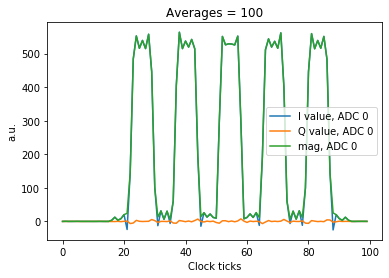

In [6]:
# Plot results
plt.figure(1)
for ii, iq in enumerate(iq_list):
    plt.plot(iq[0], label="I value, ADC %d"%(config['ro_chs'][ii]))
    plt.plot(iq[1], label="Q value, ADC %d"%(config['ro_chs'][ii]))
    plt.plot(np.abs(iq[0]+1j*iq[1]), label="mag, ADC %d"%(config['ro_chs'][ii]))
plt.ylabel("a.u.")
plt.xlabel("Clock ticks")
plt.title("Averages = " + str(config["soft_avgs"]))
plt.legend();

The phase is now automatically adjusted based on the integrated I/Q values, and the amplitude can be obtained from this plot for determining the high and low threshold values for edge counting.

# Edge Counting
### Now that we have a calculated phase, you can allow edge counting in the following cells.



### Firing pulses
* Adjust how many pulse you want per readout length by manually changing the number of pulses in `num_pulse` in `config{}`.
* Send/receive a pulse with <code> pulse_style </code> = <code> const </code>



In [7]:
class LoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg   
        res_ch = cfg["res_ch"]

        # set the nyquist zone
        self.declare_gen(ch=cfg["res_ch"], nqz=1)
        
        # configure the readout lengths and downconversion frequencies (ensuring it is an available DAC frequency)
        for ch in cfg["ro_chs"]:
            self.declare_readout(ch=ch, length=self.cfg["readout_length"],
                                 freq=self.cfg["pulse_freq"], gen_ch=cfg["res_ch"],
                                 edge_counting=self.cfg["edge_counting"],
                                 high_threshold=self.cfg["high_threshold"],
                                 low_threshold=self.cfg["low_threshold"] )

        # convert frequency to DAC frequency (ensuring it is an available ADC frequency)
        freq = self.freq2reg(cfg["pulse_freq"],gen_ch=res_ch, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]
        self.default_pulse_registers(ch=res_ch, freq=freq, phase=phase, gain=gain)
        style=self.cfg["pulse_style"]

        if style in ["flat_top","arb"]:
            sigma = cfg["sigma"]
            self.add_gauss(ch=res_ch, name="measure", sigma=sigma, length=sigma*5)
            
        if style == "const":
            self.set_pulse_registers(ch=res_ch, style=style, length=cfg["length"])
        elif style == "flat_top":
            # The first half of the waveform ramps up the pulse, the second half ramps down the pulse
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure", length=cfg["length"])
        elif style == "arb":
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure")
        
        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        # fire the pulse
        # trigger all declared ADCs
        # pulse PMOD0_0 for a scope trigger
        # pause the tProc until readout is done
        # increment the time counter to give some time before the next measurement
        # (the syncdelay also lets the tProc get back ahead of the clock)
        
        # self.measure() does trigger and pulse simultaneously 
#         self.measure(pulse_ch=self.cfg["res_ch"], 
#                      adcs=self.ro_chs,
#                      pins=[0], 
#                      adc_trig_offset=self.cfg["adc_trig_offset"],
#                      wait=True,
#                      syncdelay=self.us2cycles(self.cfg["relax_delay"]))
    
        # equivalent to the following:
        self.trigger(adcs=self.ro_chs,
                     pins=[0], 
                     adc_trig_offset=self.cfg["adc_trig_offset"])
        
        # Generate pulses x times in 'num_pulse' under config in the next cell.
        for _ in range(self.cfg["num_pulse"]):
            self.pulse(ch=config["res_ch"])  # Generate a pulse
            self.synci(10) # Time between each pulse
       
        #  Manually fire pulses line by line
#         self.pulse(ch=self.cfg["res_ch"])
#         self.synci(10)
#         self.pulse(ch=self.cfg["res_ch"])
#         self.synci(10)
#         self.pulse(ch=self.cfg["res_ch"])
#         self.synci(10)
#         self.pulse(ch=self.cfg["res_ch"])
#         self.synci(10)
#         self.pulse(ch=self.cfg["res_ch"])

        self.wait_all()
        self.sync_all(self.us2cycles(self.cfg["relax_delay"]))

# Enable Edge Triggering

* Set `edge_counting`=True
* Set `high_threshold` and `low_threshold` according to the amplitude in the previous plot above.

### Getting pulses within the readout window to count the rising front edges
#### You may need to adjust the thresholds, number of pulses and readout length as appropriate for your setup.

* `num_pulse` = The number of pulses in the readout window
* `length` = The length of each pulse that will be seen under the readout_length time window
* `readout_length` = length of readout time window

* Shift `adc_trig_offset` left or right to see the pulse clearly in the readout window
* The `res_phase`=phase_deg is based on measured IQ values in the previous cells

`acquire` will give a single number of rising edges counted.


In [8]:
config={"res_ch":GEN_CH, # --Fixed
        "ro_chs":[RO_CH], # --Fixed
        "reps":1, # --Fixed
        "relax_delay":1.0, # --us
        "res_phase":phase_deg, # --degrees; New phase
        "pulse_style": "const", # --Fixed
        "length":10, # [Clock ticks]
        # Adjust the length of each pulse. Try varying length from 10-100 clock ticks
        
        "num_pulse":8, # Change the number of the pulses
        
        "readout_length":100, # [Clock ticks]
        # Try varying readout_length from 50-1000 clock ticks

        "pulse_gain":8000, # [DAC units]
        # Try varying pulse_gain from 500 to 30000 DAC units

        "pulse_freq": 250, # [MHz]
        # In this program the signal is up and downconverted digitally so you won't see any frequency
        # components in the I/Q traces below. But since the signal gain depends on frequency, 
        # if you lower pulse_freq you will see an increased gain.

        "adc_trig_offset": 197, # [Clock ticks] 
        # Adjust the offset for a clear pulse/edge reading within the readout window 
        # Try varying adc_trig_offset from 100 to 220 clock ticks

        "soft_avgs":100, #100
        # Try varying soft_avgs from 1 to 200 averages
        
        "edge_counting":True, # set true to enable
        
        "high_threshold": 200,
        "low_threshold": 200
       }

prog = LoopbackProgram(soccfg, config)
iq_list = prog.acquire(soc, progress=True)

#IQ after applying autophaser in res_phase
print(iq_list)

iq_list = prog.acquire_decimated(soc, progress=True)

  0%|          | 0/100 [00:00<?, ?it/s]

([array([7.])], [array([0.])])


  0%|          | 0/100 [00:00<?, ?it/s]

##### Output:
   `([array([x.])], [array([0.])])` - counting x amount of edges, including the front edge that gets cut from the readout window.

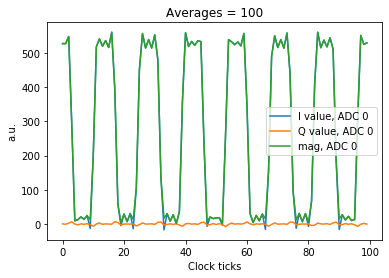

In [9]:
# Plot results.
plt.figure(1)
for ii, iq in enumerate(iq_list):
    plt.plot(iq[0], label="I value, ADC %d"%(config['ro_chs'][ii]))
    plt.plot(iq[1], label="Q value, ADC %d"%(config['ro_chs'][ii]))
    plt.plot(np.abs(iq[0]+1j*iq[1]), label="mag, ADC %d"%(config['ro_chs'][ii]))
plt.ylabel("a.u.")
plt.xlabel("Clock ticks")
plt.title("Averages = " + str(config["soft_avgs"]))
plt.legend();

The plot above shows a total of 8 pulses; however, only 7 pulses are counted, including the front rising edge of the right-most pulse, while the back edge of the left-most pulse is not counted.

### Printing the program
It's sometimes useful to print the program in ASM format, to get a feeling for what's going on.

In [10]:
print(prog)


// Program

        regwi 3, $22, 156038095;                //freq = 156038095
        regwi 3, $23, 650205890;                //phase = 650205890
        regwi 3, $25, 8000;                     //gain = 8000
        regwi 3, $26, 589834;                   //phrst| stdysel | mode | | outsel = 0b01001 | length = 10 
        synci 200;
        regwi 0, $15, 0;
        regwi 0, $14, 0;
LOOP_J: regwi 0, $16, 16385;                    //out = 0b0100000000000001
        seti 0, 0, $16, 197;                    //ch =0 out = $16 @t = 0
        seti 0, 0, $0, 207;                     //ch =0 out = 0 @t = 0
        regwi 3, $27, 0;                        //t = 0
        set 7, 3, $22, $23, $0, $25, $26, $27;  //ch = 6, pulse @t = $27
        synci 10;
        regwi 3, $27, 10;                       //t = 10
        set 7, 3, $22, $23, $0, $25, $26, $27;  //ch = 6, pulse @t = $27
        synci 10;
        regwi 3, $27, 20;                       //t = 20
        set 7, 3, $22, $23, $0, $25, $26, 

#### Quick note: Two main ways of acquiring data: [`acquire_decimated()`](https://qick-docs.readthedocs.io/latest/_autosummary/qick.averager_program.html#qick.averager_program.AveragerProgram.acquire_decimated) and [`acquire()`](https://qick-docs.readthedocs.io/latest/_autosummary/qick.averager_program.html#qick.averager_program.AveragerProgram.acquire)

In the previous demonstration we used `acquire_decimated()` which uses the QICK decimated buffer (acquiring a whole time trace of data for every measurement shot. The QICK accumulated buffer is used in `acquire()`, which acquires a single I/Q data point per measurement shot- the average of the I/Q values in the decimated buffer. In qubit experiments we will be mainly using `acquire()` since for every shot we only need one I/Q value to assess the state of the qubit.